Loading CSV...
Bigram chart saved: bigram_chart.png
Bigram CSV saved: bigrams.csv


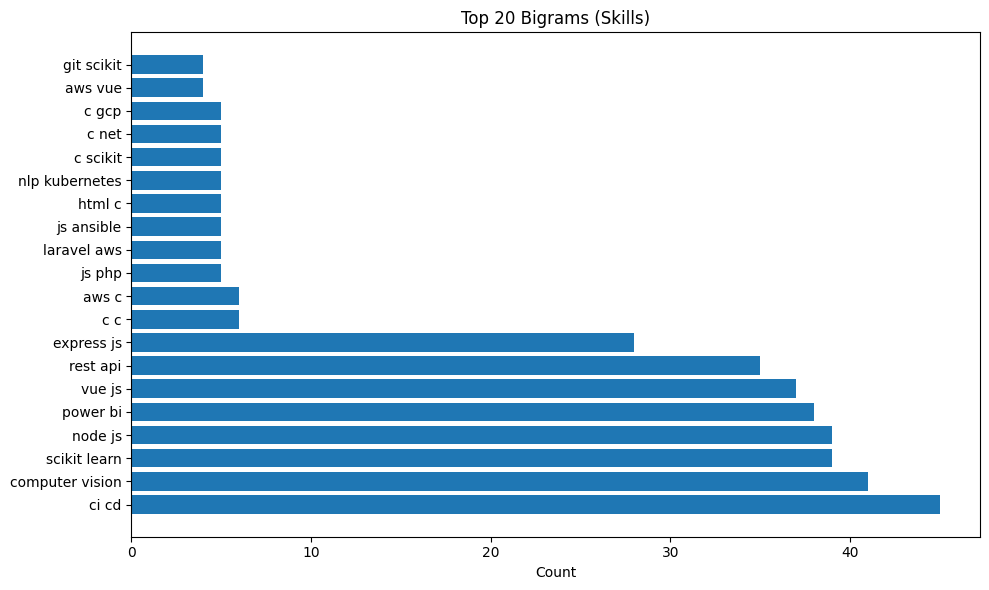

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter
from nltk.util import ngrams



def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9 ]", " ", text)
    return text

print("Loading CSV...")
df = pd.read_csv(r"jobs.csv")

skills_corpus = ""
for s in df['Skills'].dropna():
    skills_corpus += " " + clean_text(s)

words = skills_corpus.split()

bigrams = list(ngrams(words, 2))
bigram_counts = Counter(bigrams)

top_bigrams = bigram_counts.most_common(20)

labels = [f"{b[0][0]} {b[0][1]}" for b in top_bigrams]
values = [b[1] for b in top_bigrams]

plt.figure(figsize=(10,6))
plt.barh(labels, values)
plt.title("Top 20 Bigrams (Skills)")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig("bigram_chart.png")
print("Bigram chart saved: bigram_chart.png")

pd.DataFrame(top_bigrams, columns=['Bigram','Count']).to_csv("bigrams.csv", index=False)
print("Bigram CSV saved: bigrams.csv")
